## 1. Import Libraries

In [2]:
import re
import string
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, recall_score

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load Train and Test data

In [3]:
TRAIN_FILE_PATH_1 = '../data/train/mental_heath_january.csv'


df_train = pd.read_csv(TRAIN_FILE_PATH_1)

print("Test shape:", df_train.shape)
df_train.head()

Test shape: (15254, 3)


,Unique_ID,text,status
0,16433.0,I cannot imagine how anyone could want to be i...,Suicidal
1,15506.0,I just do not have anyone else to talk to abou...,Very Negative
2,52213.0,feeling of body falling anyone else gets this ...,Negative
3,42724.0,is cry inside please oh please let it rain so ...,Normal
4,37612.0,News Releases from the banquet = almost done! ...,Normal


## Setup MLFlow

In [4]:
import mlflow

mlflow.set_tracking_uri("http://ec2-18-136-206-38.ap-southeast-1.compute.amazonaws.com/")
mlflow.set_experiment("mental-health-sentiment-analysis")

<Experiment: artifact_location='s3://cu-guessing-engineering-dvc/mlflow-artifacts/2', creation_time=1774726685576, experiment_id='2', last_update_time=1774726685576, lifecycle_stage='active', name='mental-health-sentiment-analysis', tags={}, workspace='default'>

In [5]:
TEXT_COL = "text"
LABEL_COL = "status" 

## 3. Data cleaning and Pre-processing
the dataset already do these data cleaning steps
- Removed rows with missing text or labels.
- Dropped duplicate posts based on text.
- Normalized whitespace and basic formatting via regex.
- Filtered out extremely short and extremely long texts to remove non‑informative samples.

In [6]:
import re
import string
import nltk
from nltk.tokenize import word_tokenize

# ดาวน์โหลดทรัพยากรสำหรับ Preprocessing
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sahat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sahat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
def clean_text(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. remove special characters ที่ไม่ใช่ ASCII (เช่น â, €, š)
    text = text.encode("ascii", "ignore").decode()

    # 3. remove punctuation except (! and ?)
    text = re.sub(r'[^a-z0-9\s!?]', '', text)
    
    return text

# --- ตัวอย่างการทดสอบใช้งาน ---
test_input = "I'm so happy! It's 100% amazing?? â € š"
cleaned = clean_text(test_input)
print(f"Original: {test_input}")
print(f"Cleaned:  {cleaned}")
# Output ที่ได้จะเป็น: "im happy ! 100 amazing ??"

Original: I'm so happy! It's 100% amazing?? â € š
Cleaned:  im so happy! its 100 amazing??   


In [8]:
## encode label
label2id = {
    "Normal": 0,
    "Negative": 1,
    "Very Negative": 2,
    "Suicidal": 3,
}

if df_train[LABEL_COL].dtype == object:
    df_train["label_id"] = df_train[LABEL_COL].map(label2id)
    LABEL_COL_NUM = "label_id"
else:
    LABEL_COL_NUM = LABEL_COL

df_train[[TEXT_COL, LABEL_COL, LABEL_COL_NUM]].head()

,text,status,label_id
0,I cannot imagine how anyone could want to be i...,Suicidal,3
1,I just do not have anyone else to talk to abou...,Very Negative,2
2,feeling of body falling anyone else gets this ...,Negative,1
3,is cry inside please oh please let it rain so ...,Normal,0
4,News Releases from the banquet = almost done! ...,Normal,0


## 4. Train test split

In [9]:
df_train['cleaned_text'] = df_train[TEXT_COL].apply(clean_text)
X = df_train['cleaned_text']
y = df_train['label_id']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.1, 
    random_state=21, 
    stratify=y
)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)}")

Train size: 13728 | Val size: 1526


## 6. Traning model

In [10]:
# define model
# 3. สร้าง ML Pipeline
# เราจะรวม Tfidf และ LogisticRegression ไว้ด้วยกันเพื่อให้จัดการข้อมูลได้ง่ายในขั้นตอน Deployment
baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=5000)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

baseline_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [11]:
# 5. Evaluation (ตามคำแนะนำของอาจารย์)
y_pred = baseline_pipeline.predict(X_val)

macro_f1 = f1_score(y_val, y_pred, average='macro')
accuracy = accuracy_score(y_val, y_pred)
macro_recall = recall_score(y_val, y_pred, average='macro')

print("--- Validation Set Evaluation ---")
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Accuracy Score: {accuracy:.4f}")
print(f"Macro Recall Score: {macro_recall:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

--- Validation Set Evaluation ---
Macro F1 Score: 0.7550
Accuracy Score: 0.7693
Macro Recall Score: 0.7737

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       565
           1       0.71      0.90      0.79       173
           2       0.75      0.60      0.67       444
           3       0.65      0.68      0.66       344

    accuracy                           0.77      1526
   macro avg       0.75      0.77      0.75      1526
weighted avg       0.77      0.77      0.77      1526



## 6.1 ROC-AUC Curve (Validation Set)
Plot one-vs-rest ROC curves for all classes and report macro/micro AUC.

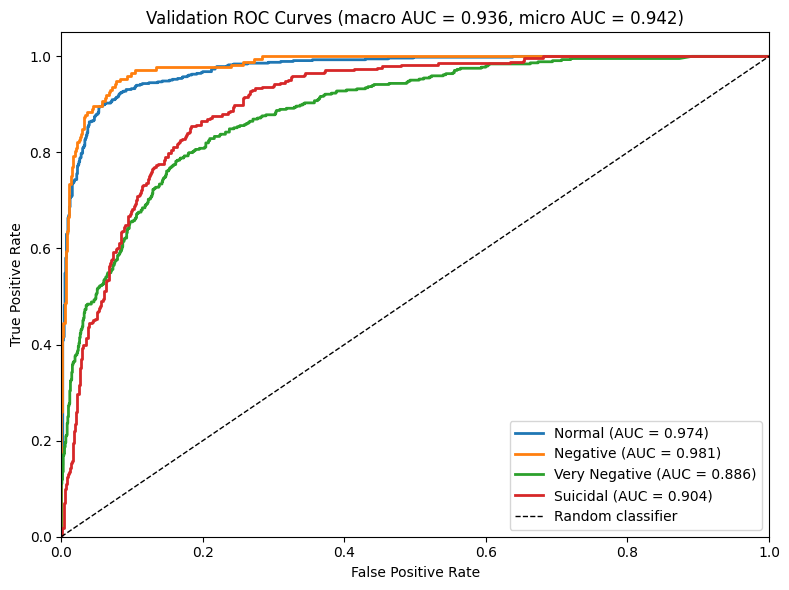

Validation Macro AUC (OvR): 0.9361
Validation Micro AUC (OvR): 0.9424


In [12]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get class probabilities from the trained pipeline
y_score = baseline_pipeline.predict_proba(X_val)

# Binarize true labels for multiclass ROC (one-vs-rest)
classes = sorted(df_train['label_id'].unique())
y_val_bin = label_binarize(y_val, classes=classes)

# Create class names mapping
id2label = {v: k for k, v in label2id.items()}
class_names = [id2label.get(c, str(c)) for c in classes]

# Per-class ROC curves
fpr = {}
tpr = {}
roc_auc = {}
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro/micro AUC scores
macro_auc = roc_auc_score(y_val_bin, y_score, average='macro', multi_class='ovr')
micro_auc = roc_auc_score(y_val_bin, y_score, average='micro', multi_class='ovr')

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], lw=2, label=f"{class_name} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Validation ROC Curves (macro AUC = {macro_auc:.3f}, micro AUC = {micro_auc:.3f})')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Validation Macro AUC (OvR): {macro_auc:.4f}")
print(f"Validation Micro AUC (OvR): {micro_auc:.4f}")

## 7. Evaluation on Test set

In [13]:
# Path inside the Kaggle dataset to the TEST FILE
TEST_FILE_PATH = '../data/test/mental_health_combined_test.csv'

df_test = pd.read_csv(TEST_FILE_PATH)


print("Test shape:", df_test.shape)
df_test.head()

Test shape: (992, 2)


,text,status
0,i don't understand whats wrong with me. i don'...,Negative
1,usually when i have anxiety just chatting with...,Negative
2,"well, i've had anxiety and panic syndrome for ...",Negative
3,"for the most minimal of things, like standing ...",Negative
4,i stay away from family and live with my roomm...,Negative


In [14]:
if df_test[LABEL_COL].dtype == object:
    df_test[LABEL_COL_NUM] = df_test[LABEL_COL].map(label2id)

df_test[[TEXT_COL, LABEL_COL, LABEL_COL_NUM]].head()

,text,status,label_id
0,i don't understand whats wrong with me. i don'...,Negative,1
1,usually when i have anxiety just chatting with...,Negative,1
2,"well, i've had anxiety and panic syndrome for ...",Negative,1
3,"for the most minimal of things, like standing ...",Negative,1
4,i stay away from family and live with my roomm...,Negative,1


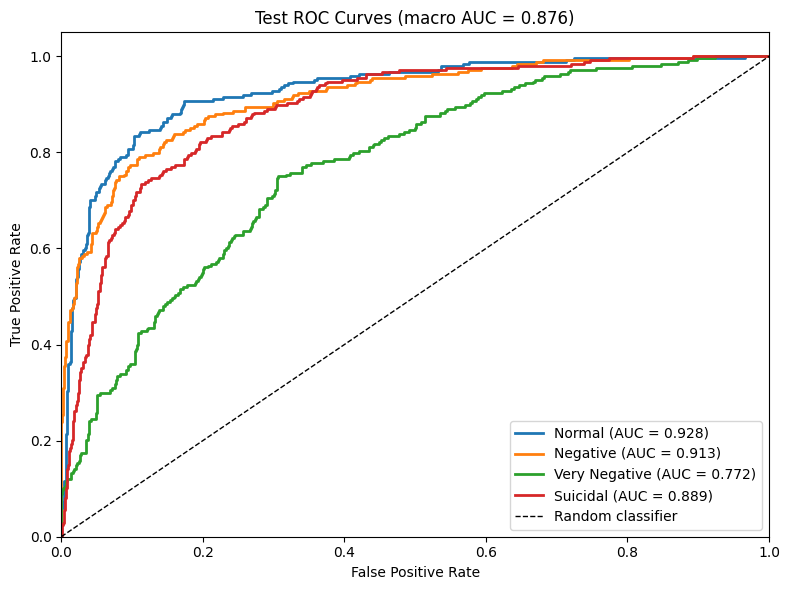

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
from mlflow.tracking import MlflowClient

df_test['cleaned_text'] = df_test[TEXT_COL].apply(clean_text)
X = df_test['cleaned_text']
y = df_test[LABEL_COL_NUM]

# model inference
y_pred = baseline_pipeline.predict(X)
y_score = baseline_pipeline.predict_proba(X)

# Build class-name mapping for plots
classes = sorted(pd.unique(y))
id2label = {v: k for k, v in label2id.items()}
class_names = [id2label.get(c, str(c)) for c in classes]

test_macro_f1 = f1_score(y, y_pred, average='macro')
test_accuracy = accuracy_score(y, y_pred)
test_macro_recall = recall_score(y, y_pred, average='macro')
test_macro_auc = roc_auc_score(y, y_score, multi_class='ovr', average='macro')

# One-vs-rest ROC curves
y_bin = label_binarize(y, classes=classes)
fpr = {}
tpr = {}
roc_auc = {}
valid_curve_idx = []

for i in range(len(classes)):
    # Skip classes that do not have both positive and negative samples in y
    if len(set(y_bin[:, i])) < 2:
        continue
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    valid_curve_idx.append(i)

fig, ax = plt.subplots(figsize=(8, 6))
for i in valid_curve_idx:
    ax.plot(fpr[i], tpr[i], lw=2, label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Test ROC Curves (macro AUC = {test_macro_auc:.3f})')
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

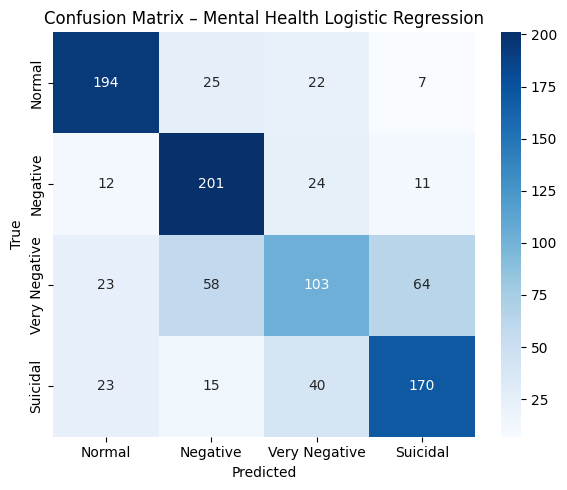

In [20]:
cm = confusion_matrix(y, y_pred)

cm_fig, cm_ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=cm_ax
)
cm_ax.set_xlabel("Predicted")
cm_ax.set_ylabel("True")
cm_ax.set_title("Confusion Matrix – Mental Health Logistic Regression")
cm_fig.tight_layout()

In [21]:
registered_model_name = "mental-health-logreg-tfidf"
registered_version = None

# Log experiment on test set
with mlflow.start_run(run_name="logreg_tfidf_test_set") as run:
    tfidf_params = baseline_pipeline.named_steps['tfidf'].get_params()
    clf_params = baseline_pipeline.named_steps['clf'].get_params()

    mlflow.log_params({
        "model_type": "LogisticRegression+TFIDF",
        "tfidf_ngram_range": str(tfidf_params.get('ngram_range')),
        "tfidf_max_features": tfidf_params.get('max_features'),
        "clf_class_weight": str(clf_params.get('class_weight')),
        "clf_max_iter": clf_params.get('max_iter'),
        "clf_C": clf_params.get('C'),
    })

    mlflow.log_metric("test_macro_f1", float(test_macro_f1))
    mlflow.log_metric("test_accuracy", float(test_accuracy))
    mlflow.log_metric("test_macro_recall", float(test_macro_recall))
    mlflow.log_metric("test_macro_auc_ovr", float(test_macro_auc))

    # Upload ROC curve figure as an artifact
    mlflow.log_figure(fig, "plots/test_roc_curve.png")

    # Upload confusion matrix figure as an artifact

    mlflow.log_figure(cm_fig, "plots/test_confusion_matrix.png")

    # Save and register the trained model in MLflow Model Registry
    mlflow.sklearn.log_model(
        sk_model=baseline_pipeline,
        artifact_path="model",
        registered_model_name=registered_model_name,
    )

    client = MlflowClient()
    versions = client.search_model_versions(
        f"name='{registered_model_name}' and run_id='{run.info.run_id}'"
    )
    if versions:
        registered_version = versions[0].version

print("--- Test Set Evaluation ---")
print(f"Macro F1 Score: {test_macro_f1:.4f}")
print(f"Accuracy Score: {test_accuracy:.4f}")
print(f"Macro Recall Score: {test_macro_recall:.4f}")
print(f"Macro AUC (OvR): {test_macro_auc:.4f}")
print(f"Registered model: {registered_model_name}")
if registered_version is not None:
    print(f"Registered model version: {registered_version}")

print("\nClassification Report:")
print(classification_report(y, y_pred))

2026/03/29 03:13:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/29 03:13:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'mental-health-logreg-tfidf' already exists. Creating a new version of this model...
2026/03/29 03:13:16 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: mental-health-logreg-tfidf, version 2
Created version '2' of model 'mental-health-logreg-tfidf'.


🏃 View run logreg_tfidf_test_set at: http://ec2-18-136-206-38.ap-southeast-1.compute.amazonaws.com/#/experiments/2/runs/8b5fa95358534006a169d9cc6c64fd69
🧪 View experiment at: http://ec2-18-136-206-38.ap-southeast-1.compute.amazonaws.com/#/experiments/2
--- Test Set Evaluation ---
Macro F1 Score: 0.6656
Accuracy Score: 0.6734
Macro Recall Score: 0.6734
Macro AUC (OvR): 0.8756
Registered model: mental-health-logreg-tfidf
Registered model version: 2

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.78       248
           1       0.67      0.81      0.73       248
           2       0.54      0.42      0.47       248
           3       0.67      0.69      0.68       248

    accuracy                           0.67       992
   macro avg       0.67      0.67      0.67       992
weighted avg       0.67      0.67      0.67       992



## 8. Multi-Version Baseline (Jan / Jan+Feb / Jan+Feb+Mar)
Train three baseline versions and log each version to MLflow using the same registered model name.

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
from mlflow.tracking import MlflowClient

TRAIN_FILE_JAN = '../data/train/mental_heath_january.csv'
TRAIN_FILE_FEB = '../data/train/mental_heath_february.csv'
TRAIN_FILE_MAR = '../data/train/mental_heath_march.csv'
TEST_FILE_PATH_MULTI = '../data/test/mental_health_combined_test.csv'

BASELINE_VERSIONS = {
    'v1_january': [TRAIN_FILE_JAN],
    'v2_jan_feb': [TRAIN_FILE_JAN, TRAIN_FILE_FEB],
    'v3_jan_feb_mar': [TRAIN_FILE_JAN, TRAIN_FILE_FEB, TRAIN_FILE_MAR],
}

REGISTERED_MODEL_NAME = 'mental-health-logreg-tfidf-baseline-series'

def load_and_prepare_train(train_files):
    train_frames = [pd.read_csv(path) for path in train_files]
    df = pd.concat(train_frames, ignore_index=True)

    if df[LABEL_COL].dtype == object:
        df['label_id'] = df[LABEL_COL].map(label2id)
        label_col_num = 'label_id'
    else:
        label_col_num = LABEL_COL

    df['cleaned_text'] = df[TEXT_COL].apply(clean_text)
    return df, label_col_num

def load_and_prepare_test(test_path):
    df = pd.read_csv(test_path)

    if df[LABEL_COL].dtype == object:
        df['label_id'] = df[LABEL_COL].map(label2id)
        label_col_num = 'label_id'
    else:
        label_col_num = LABEL_COL

    df['cleaned_text'] = df[TEXT_COL].apply(clean_text)
    return df, label_col_num

def train_and_log_version(version_name, train_files, df_test, test_label_col_num):
    df_train_v, train_label_col_num = load_and_prepare_train(train_files)

    X = df_train_v['cleaned_text']
    y = df_train_v[train_label_col_num]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.1,
        random_state=21,
        stratify=y,
    )

    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=5000)),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000)),
    ])
    pipeline.fit(X_train, y_train)

    X_test = df_test['cleaned_text']
    y_test = df_test[test_label_col_num]
    y_pred = pipeline.predict(X_test)
    y_score = pipeline.predict_proba(X_test)

    test_macro_f1 = f1_score(y_test, y_pred, average='macro')
    test_accuracy = accuracy_score(y_test, y_pred)
    test_macro_recall = recall_score(y_test, y_pred, average='macro')
    test_macro_auc = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro')

    classes = sorted(pd.unique(y_test))
    id2label = {v: k for k, v in label2id.items()}
    class_names = [id2label.get(c, str(c)) for c in classes]

    y_bin = label_binarize(y_test, classes=classes)
    fpr = {}
    tpr = {}
    roc_auc = {}
    valid_curve_idx = []

    for i in range(len(classes)):
        if len(set(y_bin[:, i])) < 2:
            continue
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        valid_curve_idx.append(i)

    fig, ax = plt.subplots(figsize=(8, 6))
    for i in valid_curve_idx:
        ax.plot(fpr[i], tpr[i], lw=2, label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{version_name} Test ROC (macro AUC = {test_macro_auc:.3f})')
    ax.legend(loc='lower right')
    fig.tight_layout()

    model_version = None
    with mlflow.start_run(run_name=f'baseline_{version_name}') as run:
        tfidf_params = pipeline.named_steps['tfidf'].get_params()
        clf_params = pipeline.named_steps['clf'].get_params()

        mlflow.log_params({
            'baseline_version': version_name,
            'train_files': ','.join(train_files),
            'train_rows': int(len(df_train_v)),
            'val_rows': int(len(X_val)),
            'test_rows': int(len(X_test)),
            'model_type': 'LogisticRegression+TFIDF',
            'tfidf_ngram_range': str(tfidf_params.get('ngram_range')),
            'tfidf_max_features': tfidf_params.get('max_features'),
            'clf_class_weight': str(clf_params.get('class_weight')),
            'clf_max_iter': clf_params.get('max_iter'),
            'clf_C': clf_params.get('C'),
        })

        mlflow.log_metric('test_macro_f1', float(test_macro_f1))
        mlflow.log_metric('test_accuracy', float(test_accuracy))
        mlflow.log_metric('test_macro_recall', float(test_macro_recall))
        mlflow.log_metric('test_macro_auc_ovr', float(test_macro_auc))
        mlflow.log_figure(fig, f'plots/{version_name}_test_roc_curve.png')

        mlflow.sklearn.log_model(
            sk_model=pipeline,
            artifact_path='model',
            registered_model_name=REGISTERED_MODEL_NAME,
        )

        client = MlflowClient()
        versions = client.search_model_versions(
            f"name='{REGISTERED_MODEL_NAME}' and run_id='{run.info.run_id}'"
        )
        if versions:
            model_version = versions[0].version

    plt.close(fig)
    print(f'{version_name}: F1={test_macro_f1:.4f}, Acc={test_accuracy:.4f}, Recall={test_macro_recall:.4f}, AUC={test_macro_auc:.4f}, ModelVersion={model_version}')

df_test_multi, test_label_col_num_multi = load_and_prepare_test(TEST_FILE_PATH_MULTI)

for version_name, train_files in BASELINE_VERSIONS.items():
    train_and_log_version(version_name, train_files, df_test_multi, test_label_col_num_multi)

print('Done. Check MLflow runs and model registry for versions 1, 2, and 3.')